# Palette Similarity — 2D Embedding

Computes a 2D layout of all palettes based on color similarity.

**Pipeline:**
1. Load `data/palettes.json`
2. Convert each palette's colors to CIELAB (perceptually uniform)
3. Build a fixed-length feature vector per palette (channel statistics)
4. Reduce to 2D with UMAP (fallback: t-SNE)
5. Save `data/palette_coords.json` for the website

**Required packages:** `numpy`, `scikit-learn`, `pandas`  
**Optional (better results):** `umap-learn`

In [1]:
import json
import math
import numpy as np
import pandas as pd
from pathlib import Path

# ── load palettes ──────────────────────────────────────────────────────────────
palettes = json.loads(Path('../data/palettes.json').read_text(encoding='utf-8'))
print(f'Loaded {len(palettes)} palettes')
palettes[0]

Loaded 2546 palettes


{'name': 'a_conica',
 'palette': ['#31241EFF',
  '#57302BFF',
  '#AD836DFF',
  '#45472FFF',
  '#5B671FFF',
  '#6C8422FF'],
 'source': 'The R package: {colRoz}',
 'kind': 'qualitative'}

In [2]:
# ── color conversion helpers ──────────────────────────────────────────────────

def hex_to_rgb(hex_color: str) -> tuple[float, float, float]:
    """Convert #RRGGBB[AA] → (r, g, b) in [0, 1]."""
    h = hex_color.lstrip('#')
    r = int(h[0:2], 16) / 255.0
    g = int(h[2:4], 16) / 255.0
    b = int(h[4:6], 16) / 255.0
    return r, g, b


def rgb_to_lab(r: float, g: float, b: float) -> tuple[float, float, float]:
    """Convert linear RGB → CIELAB (D65 illuminant)."""
    # Gamma expand (sRGB → linear)
    def expand(c):
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4

    rl, gl, bl = expand(r), expand(g), expand(b)

    # Linear RGB → XYZ (D65)
    x = rl * 0.4124564 + gl * 0.3575761 + bl * 0.1804375
    y = rl * 0.2126729 + gl * 0.7151522 + bl * 0.0721750
    z = rl * 0.0193339 + gl * 0.1191920 + bl * 0.9503041

    # Normalise by D65 white point
    x /= 0.95047
    z /= 1.08883

    def f(t):
        return t ** (1/3) if t > 0.008856 else 7.787 * t + 16/116

    fx, fy, fz = f(x), f(y), f(z)
    L = 116 * fy - 16
    a = 500 * (fx - fy)
    b_ = 200 * (fy - fz)
    return L, a, b_


def palette_to_lab(colors: list[str]) -> np.ndarray:
    """Convert list of hex colors → (N, 3) LAB array."""
    labs = []
    for c in colors:
        try:
            r, g, b = hex_to_rgb(c)
            labs.append(rgb_to_lab(r, g, b))
        except Exception:
            pass  # skip malformed
    return np.array(labs) if labs else np.zeros((1, 3))


# quick sanity check
print('black LAB:', rgb_to_lab(0, 0, 0))
print('white LAB:', rgb_to_lab(1, 1, 1))
print('red LAB  :', rgb_to_lab(1, 0, 0))

black LAB: (0.0, 0.0, 0.0)
white LAB: (100.00000386666655, -1.6666666158293708e-05, 6.666666463317483e-06)
red LAB  : (53.24079414130722, 80.09245959641109, 67.20319651585301)


In [3]:
# ── build feature matrix ──────────────────────────────────────────────────────
#
# For each palette we compute, per LAB channel:
#   mean, std, p10, p50, p90
# → 15-dimensional feature vector (5 stats × 3 channels)
# Plus: number of colors (normalised) → 16 features total

STATS = [10, 50, 90]  # percentiles

def palette_features(colors: list[str]) -> np.ndarray:
    lab = palette_to_lab(colors)   # (N, 3)
    feats = []
    for ch in range(3):
        col = lab[:, ch]
        feats.append(col.mean())
        feats.append(col.std())
        feats.extend(np.percentile(col, STATS).tolist())
    # normalised palette size (log scale)
    feats.append(math.log1p(len(colors)))
    return np.array(feats, dtype=np.float32)


records = []
X = []

for p in palettes:
    colors = p.get('palette') or p.get('colors') or []
    if not colors:
        continue
    records.append({
        'name'  : p['name'],
        'kind'  : p.get('kind', ''),
        'source': p.get('source', ''),
        'colors': colors,
    })
    X.append(palette_features(colors))

X = np.vstack(X)
print(f'Feature matrix: {X.shape}  (palettes × features)')

Feature matrix: (2546, 16)  (palettes × features)


In [4]:
# ── normalise features ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled X shape:', X_scaled.shape)

Scaled X shape: (2546, 16)


In [5]:
# ── dimensionality reduction → 2D ────────────────────────────────────────────
#
# Tries UMAP first (better neighbourhood preservation).
# Falls back to t-SNE if umap-learn is not installed.

try:
    import umap
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric='euclidean',
        random_state=42,
        verbose=True,
    )
    embedding = reducer.fit_transform(X_scaled)
    method = 'UMAP'
except ImportError:
    print('umap-learn not found → falling back to t-SNE')
    from sklearn.manifold import TSNE
    reducer = TSNE(
        n_components=2,
        perplexity=40,
        n_iter=1000,
        random_state=42,
        verbose=1,
    )
    embedding = reducer.fit_transform(X_scaled)
    method = 't-SNE'

print(f'\nMethod used: {method}')
print(f'Embedding shape: {embedding.shape}')

/Users/gcarninatto/Documents/GitHub/Color-Palette-Selector/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/gcarninatto/Documents/GitHub/Color-Palette-Selector/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Mar 11 08:55:02 2026 Construct fuzzy simplicial set
Wed Mar 11 08:55:04 2026 Finding Nearest Neighbors
Wed Mar 11 08:55:06 2026 Finished Nearest Neighbor Search
Wed Mar 11 08:55:07 2026 Construct embedding


Epochs completed:   5%| ▌          27/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


Epochs completed:  29%| ██▉        146/500 [00:00]

...

	completed  350  /  500 epochs
	completed  400  /  500 epochs


Epochs completed:  96%| █████████▌ 481/500 [00:02]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:02]

Wed Mar 11 08:55:10 2026 Finished embedding

Method used: UMAP
Embedding shape: (2546, 2)


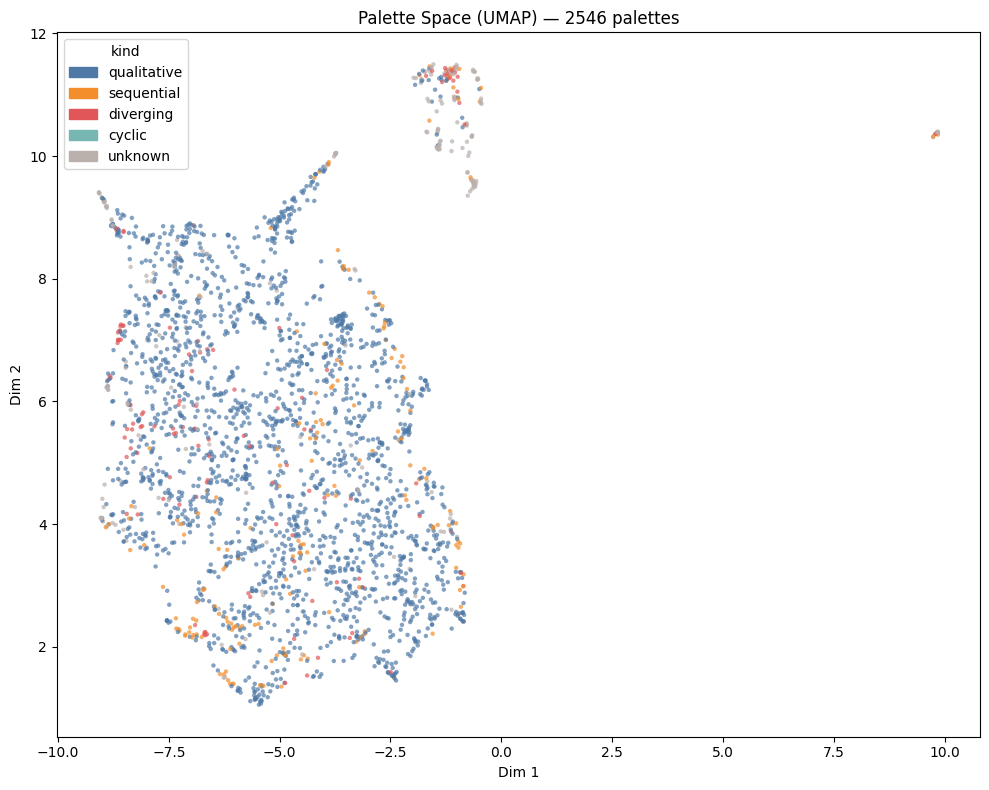

Preview saved to data/palette_space_preview.png


In [6]:
# ── quick visual check ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.DataFrame({
    'x'   : embedding[:, 0],
    'y'   : embedding[:, 1],
    'name': [r['name'] for r in records],
    'kind': [r['kind'] for r in records],
})

KIND_COLORS = {
    'qualitative' : '#4e79a7',
    'sequential'  : '#f28e2b',
    'diverging'   : '#e15759',
    'cyclic'      : '#76b7b2',
    ''            : '#bab0ac',
}
point_colors = df['kind'].map(lambda k: KIND_COLORS.get(k, KIND_COLORS['']))

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df['x'], df['y'], c=point_colors, s=10, alpha=0.7, linewidths=0)
ax.set_title(f'Palette Space ({method}) — {len(df)} palettes')
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
handles = [mpatches.Patch(color=v, label=k if k else 'unknown') for k, v in KIND_COLORS.items()]
ax.legend(handles=handles, title='kind', loc='best')
plt.tight_layout()
plt.savefig('../data/palette_space_preview.png', dpi=120)
plt.show()
print('Preview saved to data/palette_space_preview.png')

In [7]:
# ── normalise coordinates to [-1, 1] for the website ─────────────────────────
def minmax_norm(arr: np.ndarray) -> np.ndarray:
    lo, hi = arr.min(), arr.max()
    span = hi - lo
    if span == 0:
        return np.zeros_like(arr)
    return 2 * (arr - lo) / span - 1  # → [-1, 1]

x_norm = minmax_norm(embedding[:, 0])
y_norm = minmax_norm(embedding[:, 1])

# ── assemble output ───────────────────────────────────────────────────────────
output = []
for i, rec in enumerate(records):
    output.append({
        'name'  : rec['name'],
        'x'     : round(float(x_norm[i]), 4),
        'y'     : round(float(y_norm[i]), 4),
        'kind'  : rec['kind'],
        'source': rec['source'],
        'colors': rec['colors'],
    })

out_path = Path('../data/palette_coords.json')
out_path.write_text(json.dumps(output, ensure_ascii=False, separators=(',', ':')), encoding='utf-8')
print(f'Saved {len(output)} palettes → {out_path}  ({out_path.stat().st_size / 1024:.0f} KB)')

Saved 2546 palettes → ../data/palette_coords.json  (1064 KB)


In [8]:
# ── also save as JS for offline fallback ─────────────────────────────────────
js_path = Path('../data/palette_coords.js')
js_content = 'window.__PALETTE_COORDS__=' + json.dumps(output, ensure_ascii=False, separators=(',', ':')) + ';'
js_path.write_text(js_content, encoding='utf-8')
print(f'Saved JS fallback → {js_path}  ({js_path.stat().st_size / 1024:.0f} KB)')

Saved JS fallback → ../data/palette_coords.js  (1064 KB)


In [9]:
# ── validation ────────────────────────────────────────────────────────────────
sample = output[:3]
print('Sample records (first 3):')
for r in sample:
    print(f"  {r['name']:30s}  x={r['x']:+.3f}  y={r['y']:+.3f}  kind={r['kind']:15s}  n_colors={len(r['colors'])}")

kinds = pd.Series([r['kind'] for r in output]).value_counts()
print('\nKind distribution:')
print(kinds.to_string())

Sample records (first 3):
  a_conica                        x=-0.392  y=-0.726  kind=qualitative      n_colors=6
  a_palette                       x=-0.347  y=-0.208  kind=sequential       n_colors=8
  a_plagiata                      x=-0.480  y=-0.150  kind=sequential       n_colors=6

Kind distribution:
qualitative    2001
unknown         208
sequential      188
diverging       121
null             28
